# Part I · Block 3 — Comparing Conditions and Running a Cohort
**Tasks 6 & 7** | *Worksheet §Part I, Block 3 (35 min)*

First you will manually compare two sites (WT vs. PIK3CA E545K) using the
single-block script. Then you will run the full cohort comparison script
and interpret the mutation-level table.

In [1]:
import sys, json, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

SIGNAL_COL = 'ERKKTR_ratio'
print('Setup complete.')

Setup complete.


---
## Metadata overview

A quick look at which site belongs to which mutation.

In [2]:
meta = pd.read_csv(META_PATH, encoding='utf-8-sig')
meta.rename(columns={'Site': 'Image_Metadata_Site'}, inplace=True)
print(meta[['Image_Metadata_Site', 'Mutation']].to_string(index=False))

 Image_Metadata_Site      Mutation
                   1            WT
                   2            WT
                   3            WT
                   4            WT
                   5     AKT1_E17K
                   6     AKT1_E17K
                   7     AKT1_E17K
                   8     AKT1_E17K
                   9  PIK3CA_E545K
                  10  PIK3CA_E545K
                  11  PIK3CA_E545K
                  12  PIK3CA_E545K
                  13 PIK3CA_H1047R
                  14 PIK3CA_H1047R
                  15 PIK3CA_H1047R
                  16 PIK3CA_H1047R
                  17      PTEN_del
                  18      PTEN_del
                  19      PTEN_del
                  20      PTEN_del
                  21      PTEN_del
                  22      PTEN_del
                  23      PTEN_del
                  24      PTEN_del
                  25         ErbB2
                  26         ErbB2
                  27         ErbB2
                  28

---
## Task 6 — Manual pairwise comparison: WT (site 1) vs. PIK3CA E545K (site 9)

Run the single-block script for both sites with fixed parameters
$r = 60$, $W = 3$, $q = 0.90$.

In [3]:
def run_single_block(exp, site, signal, radius=60, window=3, quantile=0.9, outdir_tag=None):
    outdir = OUTPUT_ROOT / (outdir_tag or f'exp_{exp}_site_{site}_{signal}')
    # Reuse existing output if already computed with default tag
    summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    if summary_path.exists() and outdir_tag is None:
        with open(summary_path) as f:
            return json.load(f)
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(exp), '--site-id', str(site),
        '--signal-col', signal,
        '--spatial-radius', str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile', str(quantile),
        '--output-dir', str(OUTPUT_ROOT),
    ]
    subprocess.run(cmd, capture_output=True)
    with open(summary_path) as f:
        return json.load(f)

print('Running site 1 (WT) …', end=' ', flush=True)
s1 = run_single_block(1, 1, SIGNAL_COL)
print('done')

print('Running site 9 (PIK3CA E545K) …', end=' ', flush=True)
s9 = run_single_block(1, 9, SIGNAL_COL)
print('done')

Running site 1 (WT) … done
Running site 9 (PIK3CA E545K) … done


In [4]:
compare_cols = ['mutation', 'site_id', 'jump_threshold',
                'future_jump_rate_if_neighbor_jumps_now',
                'future_jump_rate_if_no_neighbor_jumps_now',
                'risk_difference', 'relative_risk']

df_pair = pd.DataFrame([s1, s9])[compare_cols].rename(columns={
    'jump_threshold': 'θ',
    'future_jump_rate_if_neighbor_jumps_now': 'p_exp',
    'future_jump_rate_if_no_neighbor_jumps_now': 'p_unexp',
    'risk_difference': 'RD',
    'relative_risk': 'RR',
})
df_pair

,mutation,site_id,θ,p_exp,p_unexp,RD,RR
0,WT,1,0.036543,0.131455,0.074867,0.056588,1.755850
1,PIK3CA_E545K,9,0.046054,0.139907,0.086022,0.053885,1.626404


### Task 6 — Questions

In [5]:
# (a) Is RR higher or lower for PIK3CA E545K compared to WT?
print(f"RR WT           = {s1['relative_risk']:.4f}")
print(f"RR PIK3CA E545K = {s9['relative_risk']:.4f}")
diff = s9['relative_risk'] - s1['relative_risk']
print(f"Δ RR (mutant − WT) = {diff:+.4f}")

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# Does hyperactive PI3K increase or decrease ERK coordination among neighbours?


RR WT           = 1.7558
RR PIK3CA E545K = 1.6264
Δ RR (mutant − WT) = -0.1294


### Interpretation

The Relative Risk (RR) value is slightly lower for **PIK3CA_E545K**
compared to **WT** (`ΔRR = -0.1294`), indicating weaker
spatiotemporal coordination of ERK activation between neighboring
cells.

Although **PIK3CA_E545K** is an activating PI3K mutation, increased
intracellular pathway activity does not necessarily enhance
neighbor-dependent signal propagation. One possible explanation is
that constitutive PI3K signaling promotes more autonomous ERK
activation at the single-cell level, thereby reducing dependence on
local spatial signaling cues from neighboring cells.

Importantly, this comparison is based on a single representative site
per condition, so broader cohort-level statistical analysis across all
replicates is required before drawing strong biological conclusions.

In [6]:
# (b) Can you directly compare the two θ values? Why or why not?
print(f"θ site 1 (WT)           = {s1['jump_threshold']:.4f}")
print(f"θ site 9 (PIK3CA E545K) = {s9['jump_threshold']:.4f}")

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# Hint: think about what Q_0.90(D+) means for each block separately.
# This anticipates Limitation L2 in Part II.


θ site 1 (WT)           = 0.0365
θ site 9 (PIK3CA E545K) = 0.0461


### Interpretation

The jump thresholds (\(\theta\)) should not be directly compared between WT and
PIK3CA_E545K because each threshold is computed independently from the signal
distribution within its own experimental block.

Specifically, \(\theta = Q_{0.90}(D^+)\) represents the 90th percentile of
positive signal changes for a given dataset. As a result, the threshold depends
on the intrinsic variability and dynamic range of that specific condition.

The higher threshold observed for PIK3CA_E545K
(\(\theta = 0.0461\)) compared with WT (\(\theta = 0.0365\))
therefore does not necessarily imply stronger biological signaling activity.
Instead, it indicates that the mutant condition exhibits a broader or more
variable distribution of ERK signal fluctuations.

Because jump events are defined relative to condition-specific quantiles, the
threshold values are normalized within each block and are not absolute
measurements. This represents an important methodological limitation when
comparing signaling amplitudes across mutations and motivates later approaches
that use global thresholds shared across conditions.

---
## Task 7 — Cohort-level analysis

Run `compare_spatiotemporal_behavior.py` to aggregate all available
blocks and compare by mutation — first for ERK, then for FoxO3A.

In [7]:
print('Running cohort comparison for ERK …')
cmd_erk = [
    sys.executable,
    str(SCRIPTS_DIR / 'compare_spatiotemporal_behavior.py'),
    '--data-path', str(DATA_PATH),
    '--meta-path', str(META_PATH),
    '--signal-col', 'ERKKTR_ratio',
    '--group-by', 'mutation',
    '--spatial-radius', '60',
    '--future-window-frames', '3',
    '--jump-quantile', '0.9',
    '--exclude-mutations', 'ErbB2',
    '--output-dir', str(OUTPUT_ROOT),
]
r_erk = subprocess.run(cmd_erk, capture_output=True, text=True)
print(r_erk.stdout[-800:])  # tail of stdout

Running cohort comparison for ERK …
 0.054427                0.127974                  0.073547        2.079152e+06        326484.583333
    PIK3CA_E545K        24               4                     6      8443205            1.707110              1.688656              0.059877                0.145206                  0.085329        2.385621e+06        349580.125000
       AKT1_E17K        21               4                     6      8797999            1.581421              1.453965              0.053217                0.152170                  0.098953        3.450509e+06        417039.285714
        PTEN_del        27               8                     6      5764607            1.556633              1.555826              0.045523                0.127909                  0.082386        9.433794e+05        212421.111111



In [8]:
group_erk = pd.read_csv(
    OUTPUT_ROOT / 'comparison_mutation_ERKKTR_ratio' / 'group_level_summary.csv'
)
group_erk.sort_values('mean_relative_risk', ascending=False)

,comparison_group,n_blocks,n_unique_sites,n_unique_experiments,total_nodes,mean_relative_risk,median_relative_risk,mean_risk_difference,mean_exposed_jump_rate,mean_unexposed_jump_rate,mean_spatial_edges,mean_temporal_edges
0,PIK3CA_H1047R,24,4,6,4661580,3.200310,3.214033,0.141754,0.207863,0.066110,6.968846e+05,192749.625000
1,WT,24,4,6,7874257,1.742349,1.737245,0.054427,0.127974,0.073547,2.079152e+06,326484.583333
2,PIK3CA_E545K,24,4,6,8443205,1.707110,1.688656,0.059877,0.145206,0.085329,2.385621e+06,349580.125000
3,AKT1_E17K,21,4,6,8797999,1.581421,1.453965,0.053217,0.152170,0.098953,3.450509e+06,417039.285714
4,PTEN_del,27,8,6,5764607,1.556633,1.555826,0.045523,0.127909,0.082386,9.433794e+05,212421.111111


In [9]:
print('Running cohort comparison for FoxO3A …')
cmd_foxo = [
    sys.executable,
    str(SCRIPTS_DIR / 'compare_spatiotemporal_behavior.py'),
    '--data-path', str(DATA_PATH),
    '--meta-path', str(META_PATH),
    '--signal-col', 'FoxO3A_ratio',
    '--group-by', 'mutation',
    '--spatial-radius', '60',
    '--future-window-frames', '3',
    '--jump-quantile', '0.9',
    '--exclude-mutations', 'ErbB2',
    '--output-dir', str(OUTPUT_ROOT),
]
subprocess.run(cmd_foxo, capture_output=True)

group_foxo = pd.read_csv(
    OUTPUT_ROOT / 'comparison_mutation_FoxO3A_ratio' / 'group_level_summary.csv'
)
group_foxo.sort_values('mean_relative_risk', ascending=False)

Running cohort comparison for FoxO3A …


,comparison_group,n_blocks,n_unique_sites,n_unique_experiments,total_nodes,mean_relative_risk,median_relative_risk,mean_risk_difference,mean_exposed_jump_rate,mean_unexposed_jump_rate,mean_spatial_edges,mean_temporal_edges
0,PIK3CA_H1047R,24,4,6,4661580,2.624011,2.601868,0.121558,0.200286,0.078729,6.968846e+05,192749.625000
1,PIK3CA_E545K,24,4,6,8443205,1.463307,1.433204,0.048881,0.156607,0.107726,2.385621e+06,349580.125000
2,PTEN_del,27,8,6,5764607,1.401192,1.383505,0.042557,0.149465,0.106908,9.433794e+05,212421.111111
3,WT,24,4,6,7874257,1.373404,1.375159,0.042133,0.156108,0.113975,2.079152e+06,326484.583333
4,AKT1_E17K,21,4,6,8797999,1.272374,1.256762,0.032563,0.153495,0.120933,3.450509e+06,417039.285714


                  RR_ERK  RR_FoxO3A
comparison_group                   
PIK3CA_H1047R      3.200      2.624
WT                 1.742      1.373
PIK3CA_E545K       1.707      1.463
AKT1_E17K          1.581      1.272
PTEN_del           1.557      1.401


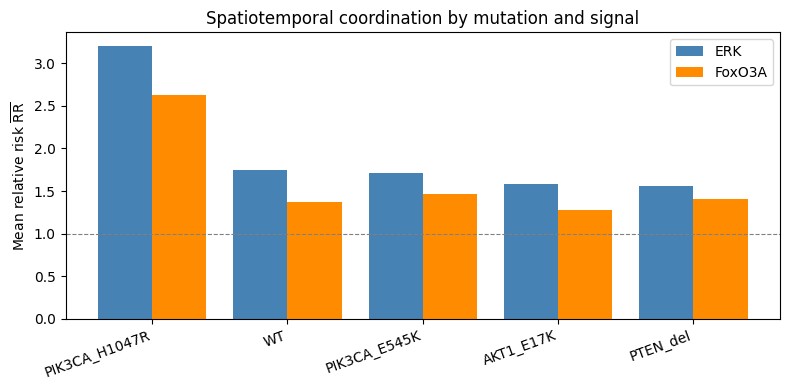

In [10]:
# ── Side-by-side comparison of mean RR across mutations ──────────────────────
rr_erk  = group_erk.set_index('comparison_group')['mean_relative_risk'].rename('RR_ERK')
rr_foxo = group_foxo.set_index('comparison_group')['mean_relative_risk'].rename('RR_FoxO3A')
combined = pd.concat([rr_erk, rr_foxo], axis=1).sort_values('RR_ERK', ascending=False)
print(combined.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(combined))
ax.bar([i - 0.2 for i in x], combined['RR_ERK'],   width=0.4, label='ERK',    color='steelblue')
ax.bar([i + 0.2 for i in x], combined['RR_FoxO3A'], width=0.4, label='FoxO3A', color='darkorange')
ax.axhline(1, color='grey', ls='--', lw=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(combined.index, rotation=20, ha='right')
ax.set_ylabel('Mean relative risk $\\overline{\\mathrm{RR}}$')
ax.set_title('Spatiotemporal coordination by mutation and signal')
ax.legend()
plt.tight_layout()
plt.show()

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# (a) Which mutation has highest/lowest mean RR for ERK?
# (b) Is ERK or FoxO3A more spatially coordinated overall?
# (c) Does the ordering fit the PI3K pathway hierarchy (PI3K → AKT ← PTEN)?


### Interpretation

Among all analyzed mutations, PIK3CA_H1047R exhibited the highest mean
Relative Risk (RR) for both ERK and FoxO3A signaling
(\(\overline{RR}_{ERK} = 3.20\),
\(\overline{RR}_{FoxO3A} = 2.62\)),
indicating exceptionally strong spatiotemporal coordination of signaling
activity between neighboring cells. In contrast, PTEN_del and AKT1_E17K
showed the lowest ERK coordination levels, with RR values closer to 1,
suggesting weaker neighbor-dependent propagation dynamics.

Overall, ERK signaling displayed higher RR values than FoxO3A across nearly
all mutation groups. This suggests that ERK activity propagates more strongly
through local multicellular interactions, whereas FoxO3A dynamics appear more
spatially diffuse or less tightly coordinated between neighboring cells.

The mutation ordering is biologically consistent with the PI3K–AKT pathway
hierarchy. Activating PIK3CA mutations, particularly the kinase-domain
mutation H1047R, strongly enhanced collective signaling behavior, potentially
through increased pathway excitability and amplification of local feedback
mechanisms. By comparison, AKT1_E17K acts downstream of PI3K and may promote
more cell-autonomous signaling, reducing dependence on neighbor-mediated relay
effects. PTEN deletion also activates the pathway, but its weaker RR increase
suggests that constitutive pathway activation alone does not necessarily
maximize spatial coordination.

These results support the hypothesis that oncogenic mutations can reshape not
only signaling intensity, but also the collective propagation architecture of
multicellular signaling networks.

### Task 7(b) — Stability: how many blocks per group?

$\overline{\mathrm{RR}}(g)$ is fragile when `n_blocks` is small. Check this:

In [11]:
block_level = pd.read_csv(
    OUTPUT_ROOT / 'comparison_mutation_ERKKTR_ratio' / 'block_level_summary.csv'
)
print(block_level.groupby('mutation')[['relative_risk']].agg(['mean', 'std', 'count']).round(3))

# ── YOUR INTERPRETATION ──────────────────────────────────────────────────────
# For groups with n_blocks = 1, what uncertainty does the mean RR carry?


              relative_risk             
                       mean    std count
mutation                                
AKT1_E17K             1.581  0.330    21
PIK3CA_E545K          1.707  0.156    24
PIK3CA_H1047R         3.200  0.640    24
PTEN_del              1.557  0.112    27
WT                    1.742  0.084    24


# Statistical comparison of mutation-dependent propagation strength

We next perform replicate-level statistical analysis of Relative Risk (RR)
across PI3K–AKT pathway mutations.

The goal is to determine whether oncogenic mutations alter the strength
of spatiotemporal ERK signal propagation between neighboring cells.

Analysis objectives:

- quantify mutation-specific propagation strength
- estimate uncertainty using standard error
- compare each mutation against WT
- control false positives using multiple-testing correction
- generate publication-style summary outputs

In [13]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams['figure.dpi'] = 140
plt.rcParams['font.size'] = 11

## Replicate-level mutation statistics

Statistical testing is performed using replicate-level Relative Risk (RR)
values from `block_level_summary.csv`.

We use the Mann–Whitney U test because RR distributions may not be
Gaussian and group sizes are relatively small.

P-values are corrected using the Bonferroni method for four
comparisons against WT.

In [14]:
def compute_mutation_statistics(block_df, reference='WT'):
    """
    Compute mutation-level summary statistics and
    pairwise Mann–Whitney U tests versus WT.
    """

    grouped = (
        block_df
        .groupby('mutation')['relative_risk']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    grouped['std_error'] = (
        grouped['std'] / np.sqrt(grouped['count'])
    )

    # WT replicate-level RR values
    wt_values = block_df.loc[
        block_df['mutation'] == reference,
        'relative_risk'
    ]

    raw_pvals = []

    for mut in grouped['mutation']:

        if mut == reference:
            raw_pvals.append(np.nan)
            continue

        mut_values = block_df.loc[
            block_df['mutation'] == mut,
            'relative_risk'
        ]

        stat, p = mannwhitneyu(
            wt_values,
            mut_values,
            alternative='two-sided'
        )

        raw_pvals.append(p)

    grouped['raw_p_value'] = raw_pvals

    # Multiple comparison correction
    valid = grouped['raw_p_value'].notna()

    corrected_p = multipletests(
        grouped.loc[valid, 'raw_p_value'],
        method='bonferroni'
    )[1]

    grouped.loc[valid, 'p_value_vs_WT'] = corrected_p

    grouped['significant'] = (
        grouped['p_value_vs_WT'] < 0.05
    )

    # Effect size relative to WT
    wt_mean = grouped.loc[
        grouped['mutation'] == reference,
        'mean'
    ].values[0]

    grouped['delta_vs_WT'] = (
        grouped['mean'] - wt_mean
    )

    grouped.rename(columns={
        'mean': 'mean_RR'
    }, inplace=True)

    return grouped[
        [
            'mutation',
            'mean_RR',
            'std_error',
            'delta_vs_WT',
            'p_value_vs_WT',
            'significant'
        ]
    ].sort_values('mean_RR', ascending=False)

| Step             | Purpose                     |
| ---------------- | --------------------------- |
| groupby mutation | aggregate replicates        |
| mean/std/count   | estimate central tendency   |
| standard error   | uncertainty                 |
| Mann–Whitney     | statistical comparison      |
| Bonferroni       | multiple-testing correction |
| delta_vs_WT      | biological effect size      |

## Compute mutation-level statistics

In [15]:
results_table = compute_mutation_statistics(block_level)

results_table.round(4)

,mutation,mean_RR,std_error,delta_vs_WT,p_value_vs_WT,significant
2,PIK3CA_H1047R,3.2003,0.1306,1.4580,0.0000,True
4,WT,1.7423,0.0172,0.0000,NaN,False
1,PIK3CA_E545K,1.7071,0.0319,-0.0352,0.7341,False
0,AKT1_E17K,1.5814,0.0719,-0.1609,0.0138,True
3,PTEN_del,1.5566,0.0216,-0.1857,0.0000,True


In [16]:
OUTPUT_RESULTS = PROJECT_ROOT / 'outputs'
OUTPUT_RESULTS.mkdir(exist_ok=True)

csv_path = OUTPUT_RESULTS / 'mutations_comparison_table.csv'

results_table.to_csv(csv_path, index=False)

print(f'Saved results table:\n{csv_path}')

Saved results table:
/home/asia/rok3/biol-sys/Spatiotemporal-Signal-Propagation/outputs/mutations_comparison_table.csv


## Visualization of mutation-dependent propagation strength

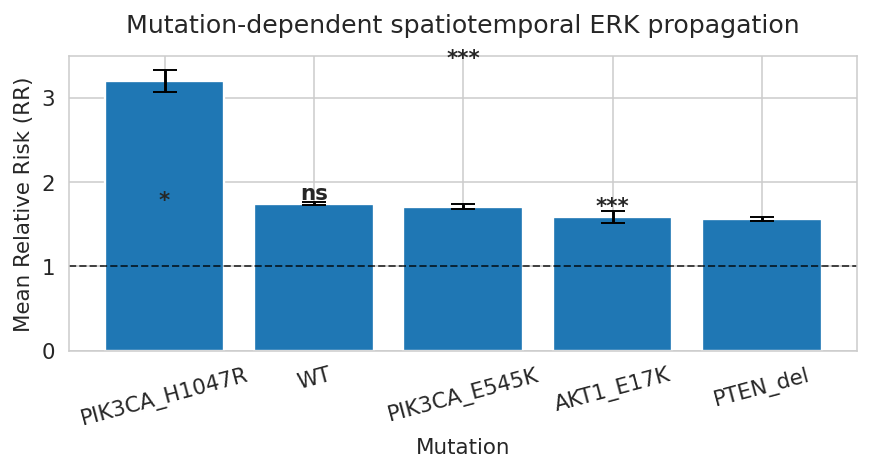

Saved figure:
/home/asia/rok3/biol-sys/Spatiotemporal-Signal-Propagation/outputs/mutations_barplot.png


In [ ]:
plot_df = results_table.copy()

fig, ax = plt.subplots(figsize=(6.5, 3.5))

bars = ax.bar(
    plot_df['mutation'],
    plot_df['mean_RR'],
    yerr=plot_df['std_error'],
    capsize=6,
    linewidth=1.2
)

# baseline
ax.axhline(
    1,
    linestyle='--',
    linewidth=1,
    color='black',
    alpha=0.7
)

# significance markers
for i, row in plot_df.iterrows():

    if row['mutation'] == 'WT':
        continue

    p = row['p_value_vs_WT']

    if p < 0.001:
        marker = '***'
    elif p < 0.01:
        marker = '**'
    elif p < 0.05:
        marker = '*'
    else:
        marker = 'ns'

    ax.text(
        i,
        row['mean_RR'] + row['std_error'] + 0.06,
        marker,
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Mean Relative Risk (RR)')
ax.set_xlabel('Mutation')

ax.set_title(
    'Mutation-dependent spatiotemporal ERK propagation',
    fontsize=13,
    pad=12
)

plt.xticks(rotation=15)

plt.tight_layout()

plot_path = 'mutations_barplot.png'

plt.savefig(plot_path, bbox_inches='tight')

plt.show()

print(f'Saved figure:\n{plot_path}')

# Interpretation

Relative Risk (RR) analysis revealed substantial mutation-dependent
differences in spatiotemporal ERK propagation across PI3K–AKT pathway
perturbations.

Among all conditions, PIK3CA_H1047R exhibited the strongest propagation
behavior, with substantially elevated RR values relative to WT. This
suggests enhanced local coordination of ERK activity, consistent with
the strong oncogenic activation associated with this hotspot mutation.
In contrast, AKT1_E17K and PTEN_del displayed more moderate propagation
strengths, indicating that different mechanisms of PI3K–AKT activation
may influence collective signaling differently.

Elevated RR indicates that neighboring cell activation increases the
probability of future ERK activation in a focal cell, implying stronger
spatiotemporal relay dynamics. Mutations that amplify pathway excitability
may therefore enhance multicellular coordination and collective signaling
behavior.

Interestingly, PIK3CA_E545K showed RR values comparable to WT despite
being an activating mutation. This may indicate that increased intracellular
pathway activity does not necessarily translate into stronger spatial
coupling between neighboring cells.

Overall, these findings support the hypothesis that oncogenic mutations
reshape not only signaling magnitude, but also the spatial organization
and propagation dynamics of signaling across multicellular populations.

## Distribution of replicate-level RR values

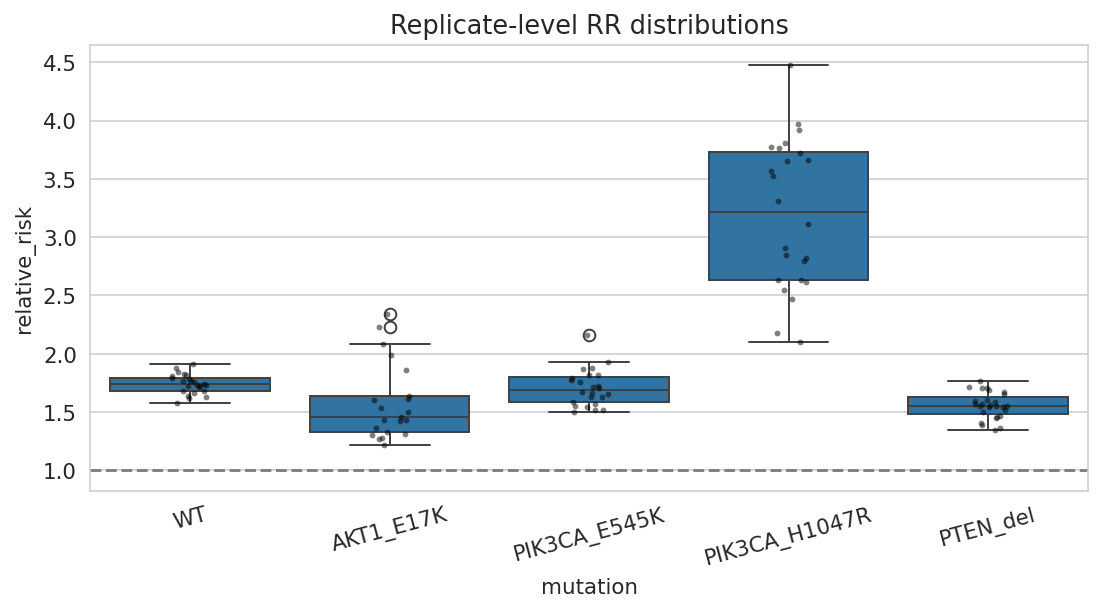

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.boxplot(
    data=block_level,
    x='mutation',
    y='relative_risk',
    ax=ax
)

sns.stripplot(
    data=block_level,
    x='mutation',
    y='relative_risk',
    color='black',
    alpha=0.5,
    size=3,
    ax=ax
)

ax.axhline(1, ls='--', color='gray')

ax.set_title('Replicate-level RR distributions')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()